Data Preprocessing, upload the files

In [2]:
import io
import math as mt
import numpy as np
import pandas as pd
import seaborn as sns
import statistics as st
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

from google.colab import files
import io
import pandas as pd

uploaded = files.upload()

filename = next(iter(uploaded))   # actual uploaded name

headerList = ['Buying','Maint','Doors','Persons','Lug_boot','Safety','Evaluation']

dataset = pd.read_csv(io.BytesIO(uploaded[filename]), names=headerList, header=None)
dataset.head()

Saving car_evaluation.csv to car_evaluation.csv


,Buying,Maint,Doors,Persons,Lug_boot,Safety,Evaluation
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


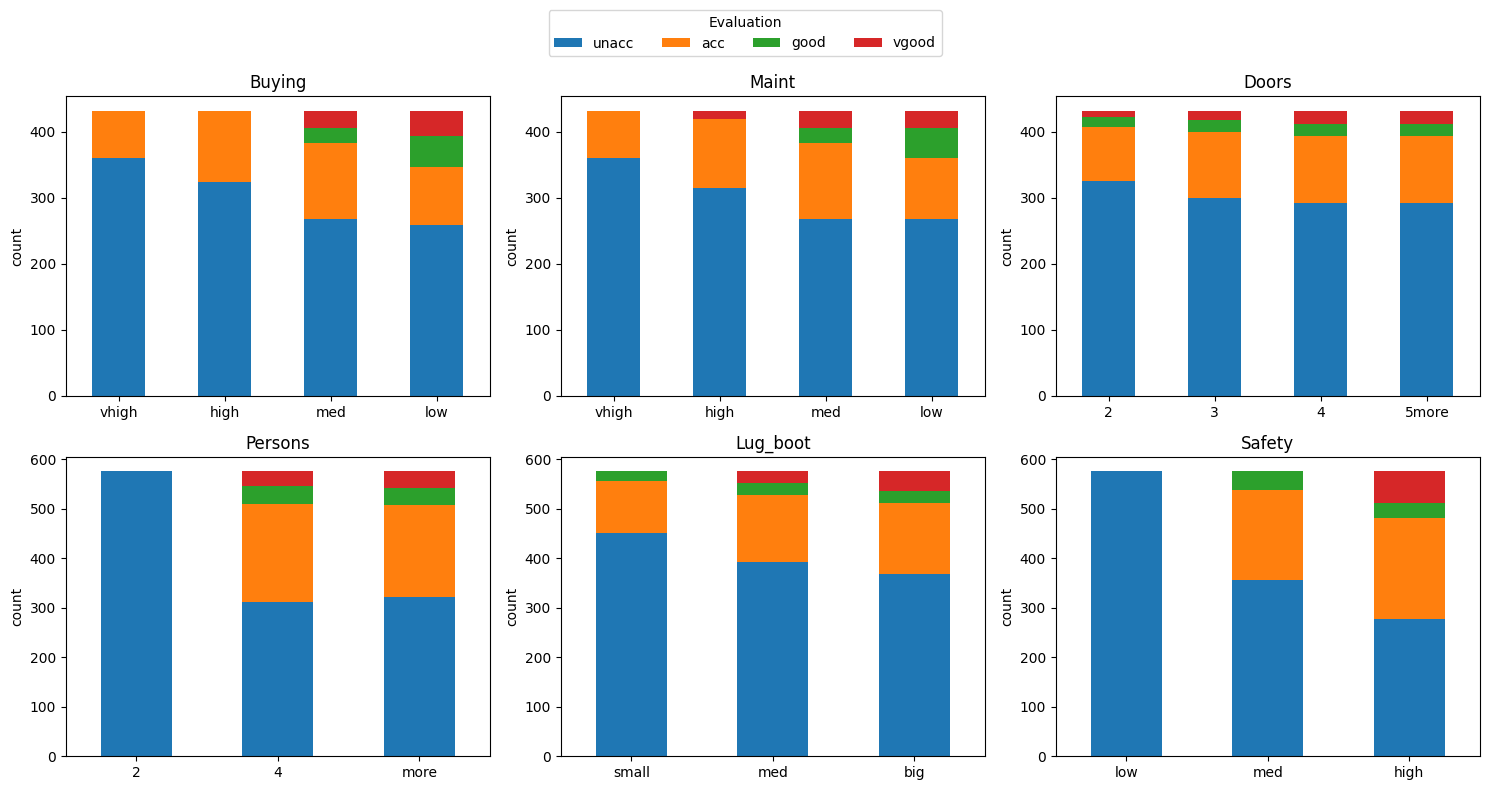

In [3]:
target = dataset.columns[-1]  # select target class
features = dataset.columns[:-1] # select input features


class_order = ["unacc", "acc", "good", "vgood"]
row_orders = {
    "Buying":   ["vhigh", "high", "med", "low"],
    "Maint":    ["vhigh", "high", "med", "low"],
    "Doors":    ["2", "3", "4", "5more"],
    "Persons":  ["2", "4", "more"],
    "Lug_boot": ["small", "med", "big"],
    "Safety":   ["low", "med", "high"],
}

# bigger figure
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, feat in enumerate(features):
    ct = pd.crosstab(dataset[feat], dataset[target])
    ct = ct.reindex(index=row_orders[feat], columns=class_order, fill_value=0)

    ax = axes[i]
    ct.plot(kind="bar", stacked=True, ax=ax, legend=False)
    ax.set_title(feat, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("count", fontsize=10)
    ax.tick_params(axis="x", rotation=0, labelsize=10)
    ax.tick_params(axis="y", labelsize=10)

handles, labels = axes[0].get_legend_handles_labels()
fig.tight_layout(rect=[0, 0, 1, 0.92])

# put legend in that reserved space
fig.legend(handles, labels, title=target,
           loc="upper center", bbox_to_anchor=(0.5, 0.99),
           ncol=len(class_order))
plt.show()


In [6]:
import pandas as pd

# filter safety == low
sub = dataset[dataset["Safety"] == "low"]

# each other feature, count appearances of each value
features_to_count = [c for c in dataset.columns if c != "Safety"]

counts = []
for feature in features_to_count:
    vc = sub[feature].value_counts()
    vc.name = feature
    counts.append(vc)

# combine into a 2D matrix
matrix = pd.concat(counts, axis=1).fillna(0).astype(int)

# remove index name to avoid Colab display conflict
matrix.index.name = None

matrix

,Buying,Maint,Doors,Persons,Lug_boot,Evaluation
vhigh,144,144,0,0,0,0
high,144,144,0,0,0,0
med,144,144,0,0,192,0
low,144,144,0,0,0,0
2,0,0,144,192,0,0
3,0,0,144,0,0,0
4,0,0,144,192,0,0
5more,0,0,144,0,0,0
more,0,0,0,192,0,0
small,0,0,0,0,192,0


In [7]:
import pandas as pd

# filter Persons == "2"
sub = dataset[dataset["Persons"] == "2"]

# count each value for every other column
cols = [c for c in dataset.columns if c != "Persons"]

matrix = pd.concat(
    [sub[c].value_counts().rename(c) for c in cols],
    axis=1
).fillna(0).astype(int)

matrix


,Buying,Maint,Doors,Lug_boot,Safety,Evaluation
vhigh,144,144,0,0,0,0
high,144,144,0,0,192,0
med,144,144,0,192,192,0
low,144,144,0,0,192,0
2,0,0,144,0,0,0
3,0,0,144,0,0,0
4,0,0,144,0,0,0
5more,0,0,144,0,0,0
small,0,0,0,192,0,0
big,0,0,0,192,0,0
